# 05c — Machine Learning Comparison (Weekly Version)

**Goal:** decide which gradient boosting champion advances to the final tournament in notebook 07.

**Methodology:** load the saved predictions from 05a (XGBoost) and 05b (LightGBM), compare them on:
- Overall metrics (val + test)
- Per-item head-to-head wins
- Per-section breakdown
- Per-volume-tier breakdown
- Wilcoxon signed-rank test (statistical significance)
- Strategic trade-offs (training time, interpretability, deployment)
- Final 3-criterion decision report (mirrors 04c structure)

**Bar to clear:** both models must beat Prophet's test WAPE 0.2837 and R² 0.6196.


## 1. Setup and load both models' outputs


In [12]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATASETS_DIR = '../../datasets'
LIGHTGBM_DIR = '../LightGbm'
XGBOOST_DIR = '../XGboost' 
PROPHET_DIR = '../Prophet' 


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Load predictions
xgb_pred = pd.read_csv(os.path.join(XGBOOST_DIR, 'xgboost_weekly_predictions.csv'),
                       parse_dates=['ds'])
lgb_pred = pd.read_csv(os.path.join(LIGHTGBM_DIR, 'lightgbm_weekly_predictions.csv'),
                       parse_dates=['ds'])

# Load metrics
xgb_metrics = pd.read_csv(os.path.join(XGBOOST_DIR, 'xgboost_weekly_metrics.csv'))
lgb_metrics = pd.read_csv(os.path.join(LIGHTGBM_DIR, 'lightgbm_weekly_metrics.csv'))

# Load summaries
with open(os.path.join(XGBOOST_DIR, 'xgboost_weekly_summary.json')) as f:
    xgb_summary = json.load(f)
with open(os.path.join(LIGHTGBM_DIR, 'lightgbm_weekly_summary.json')) as f:
    lgb_summary = json.load(f)

# Also load Prophet's summary as the bar to clear
with open(os.path.join(PROPHET_DIR, 'prophet_summary_weekly.json')) as f:
    prophet_summary = json.load(f)

print(f"XGBoost:  {len(xgb_pred):,} predictions, {xgb_metrics['item_name'].nunique()} items")
print(f"LightGBM: {len(lgb_pred):,} predictions, {lgb_metrics['item_name'].nunique()} items")
print(f"Prophet bar: test WAPE {prophet_summary['overall_metrics']['test']['wape']:.4f}, test R² {prophet_summary['overall_metrics']['test']['r2']:.4f}")


XGBoost:  6,344 predictions, 122 items
LightGBM: 6,344 predictions, 122 items
Prophet bar: test WAPE 0.2837, test R² 0.6196


## 2. Side-by-side overall metrics


OVERALL METRICS — XGBoost vs LightGBM (with Prophet as reference)
             Model Split    MAE   RMSE   WAPE  sMAPE     R²    Bias
           XGBoost   val 2.3756 3.0643 0.3073 0.3740 0.6579 -0.4843
          LightGBM   val 2.3660 3.0487 0.3061 0.3744 0.6614 -0.3490
Prophet (baseline)   val 2.8865 3.7282 0.3734 0.4287 0.4937 -0.7891
           XGBoost  test 2.6723 3.4845 0.2614 0.3063 0.6707  0.2637
          LightGBM  test 2.6755 3.4983 0.2617 0.3059 0.6681  0.2804
Prophet (baseline)  test 2.9010 3.7452 0.2837 0.3322 0.6196 -0.0743


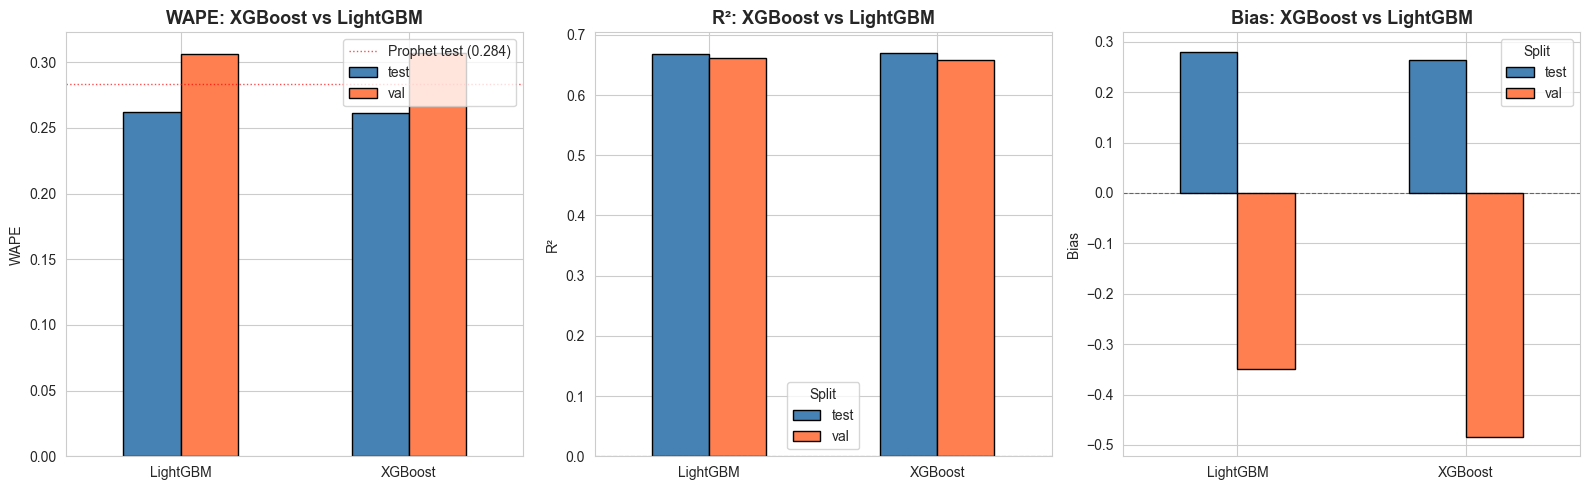

In [13]:
rows = []
for split in ['val', 'test']:
    for name, summary in [('XGBoost', xgb_summary), ('LightGBM', lgb_summary), ('Prophet (baseline)', prophet_summary)]:
        m = summary['overall_metrics'][split]
        rows.append({
            'Model': name, 'Split': split,
            'MAE': m['mae'], 'RMSE': m['rmse'],
            'WAPE': m['wape'], 'sMAPE': m.get('smape', np.nan),
            'R²': m['r2'], 'Bias': m['bias'],
        })

overall_df = pd.DataFrame(rows)
print("=" * 80)
print("OVERALL METRICS — XGBoost vs LightGBM (with Prophet as reference)")
print("=" * 80)
print(overall_df.to_string(index=False, float_format='%.4f'))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ml_only = overall_df[overall_df['Model'].isin(['XGBoost', 'LightGBM'])]
for ax, metric in zip(axes, ['WAPE', 'R²', 'Bias']):
    pivot = ml_only.pivot(index='Model', columns='Split', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'{metric}: XGBoost vs LightGBM')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.legend(title='Split')
    ax.tick_params(axis='x', rotation=0)
    if metric in ['R²', 'Bias']:
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    # Add Prophet reference line
    if metric == 'WAPE':
        prophet_test = prophet_summary['overall_metrics']['test']['wape']
        ax.axhline(prophet_test, color='red', linewidth=1, linestyle=':', alpha=0.7,
                   label=f'Prophet test ({prophet_test:.3f})')
        ax.legend(title='', loc='best')
plt.tight_layout()
plt.savefig('ml_overall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Per-item head-to-head: how often does each model win?


PER-ITEM HEAD-TO-HEAD
Split Metric  XGBoost wins  LightGBM wins  Ties XGB win %
  val   wape            55             67     0     45.1%
  val    mae            55             67     0     45.1%
  val     r2            50             72     0     41.0%
 test   wape            57             65     0     46.7%
 test    mae            57             65     0     46.7%
 test     r2            64             58     0     52.5%


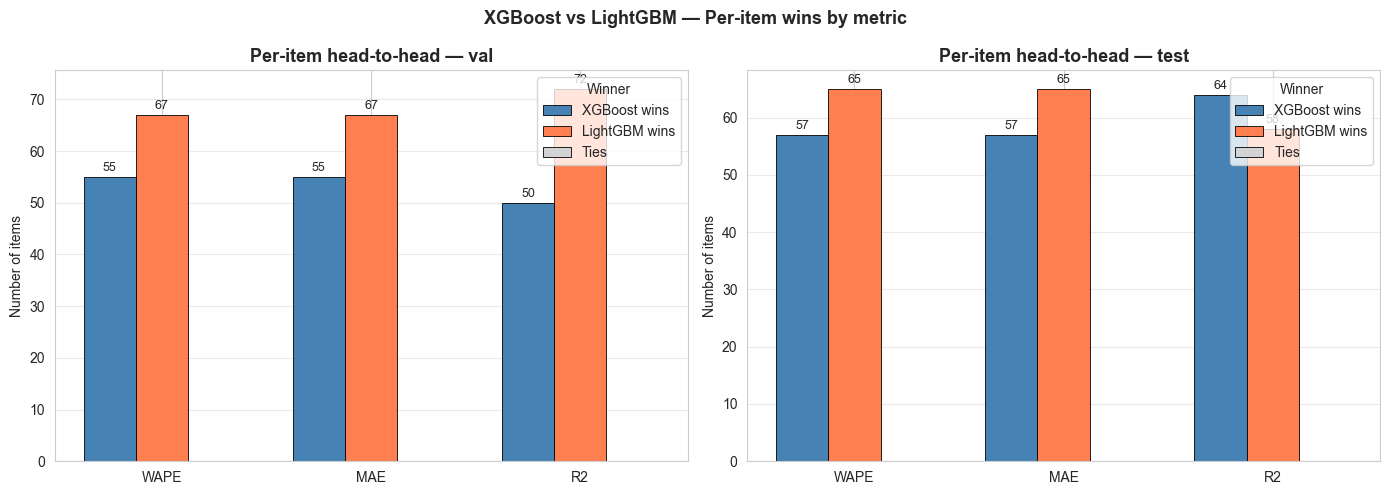

In [14]:
head_to_head = []
for split in ['val', 'test']:
    xgb_split = xgb_metrics[xgb_metrics['split'] == split].set_index('item_name')
    lgb_split = lgb_metrics[lgb_metrics['split'] == split].set_index('item_name')
    common_items = sorted(set(xgb_split.index) & set(lgb_split.index))

    for metric in ['wape', 'mae', 'r2']:
        xgb_vals = xgb_split.loc[common_items, metric]
        lgb_vals = lgb_split.loc[common_items, metric]
        if metric == 'r2':
            xgb_wins = (xgb_vals > lgb_vals).sum()
            lgb_wins = (lgb_vals > xgb_vals).sum()
        else:
            xgb_wins = (xgb_vals < lgb_vals).sum()
            lgb_wins = (lgb_vals < xgb_vals).sum()
        ties = len(common_items) - xgb_wins - lgb_wins
        head_to_head.append({
            'Split': split, 'Metric': metric,
            'XGBoost wins': xgb_wins,
            'LightGBM wins': lgb_wins,
            'Ties': ties,
            'XGB win %': f"{xgb_wins / len(common_items) * 100:.1f}%",
        })

h2h_df = pd.DataFrame(head_to_head)
print("=" * 70)
print("PER-ITEM HEAD-TO-HEAD")
print("=" * 70)
print(h2h_df.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ['val', 'test']):
    sub = h2h_df[h2h_df['Split'] == split].copy()
    metrics = sub['Metric'].str.upper().tolist()
    xgb_wins = sub['XGBoost wins'].tolist()
    lgb_wins = sub['LightGBM wins'].tolist()
    ties = sub['Ties'].tolist()
    x = np.arange(len(metrics))
    width = 0.25

    b1 = ax.bar(x - width, xgb_wins, width, label='XGBoost wins',
                color='steelblue', edgecolor='black', linewidth=0.6)
    b2 = ax.bar(x, lgb_wins, width, label='LightGBM wins',
                color='coral', edgecolor='black', linewidth=0.6)
    b3 = ax.bar(x + width, ties, width, label='Ties',
                color='lightgray', edgecolor='black', linewidth=0.6)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                        str(int(h)), ha='center', va='bottom', fontsize=9)

    ax.set_title(f'Per-item head-to-head — {split}', fontweight='bold')
    ax.set_ylabel('Number of items')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend(title='Winner')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('XGBoost vs LightGBM — Per-item wins by metric', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_h2h_wins.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-section comparison


PER-SECTION WAPE COMPARISON
      Section Split  LightGBM  XGBoost  Δ (XGB − LGB)   Winner
     American  test    0.2250   0.2241        -0.0009  XGBoost
     American   val    0.2802   0.2852         0.0050 LightGBM
         Cafe  test    0.2278   0.2270        -0.0008  XGBoost
         Cafe   val    0.2644   0.2482        -0.0163  XGBoost
Healthy_Vegan  test    0.2964   0.2990         0.0026 LightGBM
Healthy_Vegan   val    0.3348   0.3568         0.0221 LightGBM
      Italian  test    0.2774   0.2780         0.0007 LightGBM
      Italian   val    0.3187   0.3205         0.0018 LightGBM
     Japanese  test    0.2810   0.2779        -0.0030  XGBoost
     Japanese   val    0.3233   0.3320         0.0086 LightGBM
      Mexican  test    0.2806   0.2803        -0.0003  XGBoost
      Mexican   val    0.3184   0.3128        -0.0056  XGBoost
   Steakhouse  test    0.3146   0.3161         0.0015 LightGBM
   Steakhouse   val    0.3623   0.3712         0.0089 LightGBM


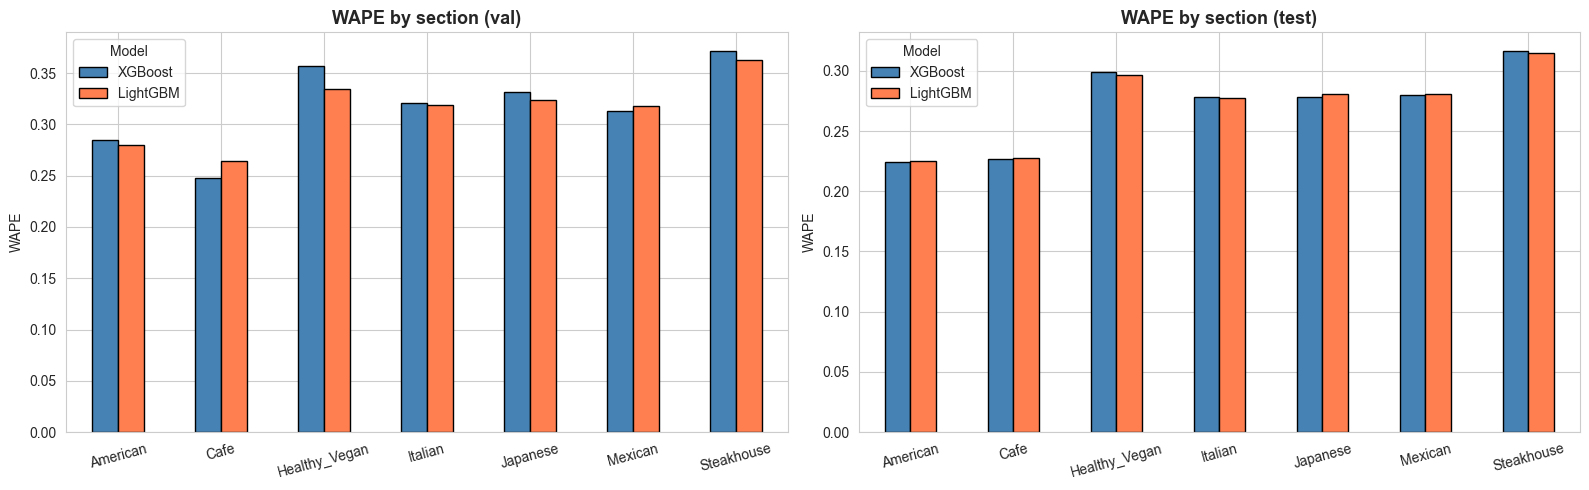

In [15]:
# 1. Grab the section mapping from the original dataset
df_orig = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'))
section_map = df_orig[['item_name', 'section', 'category']].drop_duplicates().reset_index(drop=True)

# 2. Merge the 'section' column into your prediction dataframes
xgb_pred = xgb_pred.merge(section_map, on='item_name', how='left')
lgb_pred = lgb_pred.merge(section_map, on='item_name', how='left')

# 3. Run your original comparison loop
section_compare = []
for split in ['val', 'test']:
    for model_name, pred_df in [('XGBoost', xgb_pred), ('LightGBM', lgb_pred)]:
        sub = pred_df[pred_df['split'] == split].copy()
        for section in sorted(sub['section'].unique()):
            sec_data = sub[sub['section'] == section]
            actual = sec_data['actual'].values
            predicted = sec_data['predicted'].values
            if len(actual) == 0 or actual.sum() == 0:
                continue
            mae = np.mean(np.abs(actual - predicted))
            wape = np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))
            section_compare.append({
                'Section': section, 'Split': split, 'Model': model_name,
                'MAE': mae, 'WAPE': wape, 'n_items': sec_data['item_name'].nunique(),
            })

section_df = pd.DataFrame(section_compare)
section_pivot = section_df.pivot_table(index=['Section', 'Split'], columns='Model',
                                        values='WAPE').reset_index()
section_pivot['Δ (XGB − LGB)'] = section_pivot['XGBoost'] - section_pivot['LightGBM']
section_pivot['Winner'] = np.where(section_pivot['XGBoost'] < section_pivot['LightGBM'],
                                    'XGBoost', 'LightGBM')

print("=" * 80)
print("PER-SECTION WAPE COMPARISON")
print("=" * 80)
print(section_pivot.to_string(index=False, float_format='%.4f'))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, split in zip(axes, ['val', 'test']):
    sub = section_pivot[section_pivot['Split'] == split].copy()
    sub = sub.set_index('Section')[['XGBoost', 'LightGBM']]
    sub.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_title(f'WAPE by section ({split})')
    ax.set_ylabel('WAPE'); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Model')
plt.tight_layout()
plt.savefig('ml_section_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-volume-tier comparison


PER-VOLUME-TIER WAPE COMPARISON
            Tier Split  LightGBM  XGBoost  Δ (XGB − LGB)
     Low (<7/wk)  test    0.3470   0.3489         0.0019
     Low (<7/wk)   val    0.4084   0.4165         0.0081
Medium (7-35/wk)  test    0.2386   0.2377        -0.0009
Medium (7-35/wk)   val    0.2778   0.2771        -0.0006


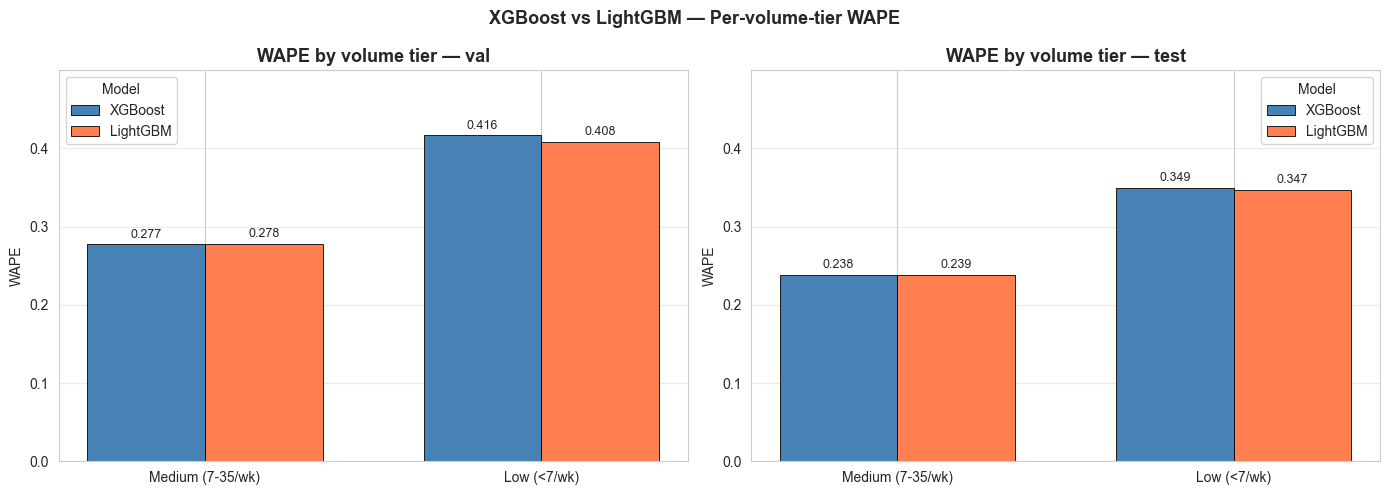

In [16]:
# Compute volume tiers from the original weekly data
df_orig = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'),
                       parse_dates=['week_start'])
item_volume = df_orig[df_orig['split']=='train'].groupby('item_name')['quantity'].mean()

def assign_tier(avg):
    if avg >= 35: return 'High (≥35/wk)'
    elif avg >= 7: return 'Medium (7-35/wk)'
    else: return 'Low (<7/wk)'

item_tiers = item_volume.apply(assign_tier).rename('volume_tier').reset_index()

tier_compare = []
for split in ['val', 'test']:
    for model_name, pred_df in [('XGBoost', xgb_pred), ('LightGBM', lgb_pred)]:
        sub = pred_df[pred_df['split'] == split].merge(item_tiers, on='item_name')
        for tier in ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']:
            tier_data = sub[sub['volume_tier'] == tier]
            if len(tier_data) == 0 or tier_data['actual'].sum() == 0:
                continue
            actual = tier_data['actual'].values
            predicted = tier_data['predicted'].values
            tier_compare.append({
                'Tier': tier, 'Split': split, 'Model': model_name,
                'MAE': np.mean(np.abs(actual - predicted)),
                'WAPE': np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual)),
                'n_items': tier_data['item_name'].nunique(),
            })

tier_df = pd.DataFrame(tier_compare)
tier_pivot = tier_df.pivot_table(index=['Tier', 'Split'], columns='Model',
                                  values='WAPE').reset_index()
tier_pivot['Δ (XGB − LGB)'] = tier_pivot['XGBoost'] - tier_pivot['LightGBM']

print("=" * 80)
print("PER-VOLUME-TIER WAPE COMPARISON")
print("=" * 80)
print(tier_pivot.to_string(index=False, float_format='%.4f'))

# ── Plot ──────────────────────────────────────────────────────────
tiers_order = ['High (≥35/wk)', 'Medium (7-35/wk)', 'Low (<7/wk)']
colors = {'XGBoost': 'steelblue', 'LightGBM': 'coral'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split in zip(axes, ['val', 'test']):
    sub = tier_df[tier_df['Split'] == split].copy()
    present_tiers = [t for t in tiers_order if t in sub['Tier'].values]
    x = np.arange(len(present_tiers))
    width = 0.35

    for idx, model in enumerate(['XGBoost', 'LightGBM']):
        model_data = sub[sub['Model'] == model].set_index('Tier')
        wape_vals = [model_data.loc[t, 'WAPE'] if t in model_data.index else 0
                     for t in present_tiers]
        bars = ax.bar(x + idx * width - width/2, wape_vals, width,
                      label=model, color=colors[model], edgecolor='black', linewidth=0.6)
        for bar, val in zip(bars, wape_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'WAPE by volume tier — {split}', fontweight='bold')
    ax.set_ylabel('WAPE')
    ax.set_xticks(x)
    ax.set_xticklabels(present_tiers, fontsize=10)
    ax.legend(title='Model')
    ax.set_ylim(0, tier_df['WAPE'].max() * 1.2)
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('XGBoost vs LightGBM — Per-volume-tier WAPE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_tier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-item WAPE scatter


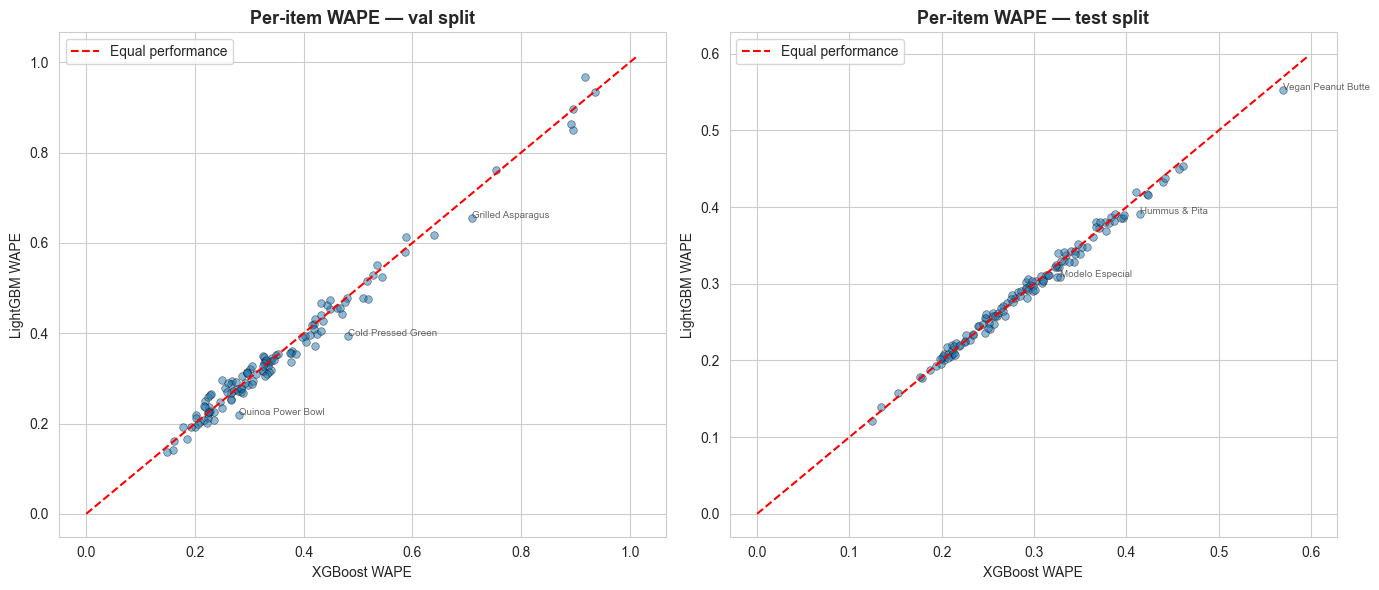

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, split in zip(axes, ['val', 'test']):
    xgb_split = xgb_metrics[xgb_metrics['split']==split].set_index('item_name')['wape']
    lgb_split = lgb_metrics[lgb_metrics['split']==split].set_index('item_name')['wape']
    common = sorted(set(xgb_split.index) & set(lgb_split.index))
    x = xgb_split.loc[common].values
    y = lgb_split.loc[common].values

    ax.scatter(x, y, alpha=0.5, s=30, edgecolor='black', linewidth=0.5)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Equal performance')
    ax.set_xlabel('XGBoost WAPE'); ax.set_ylabel('LightGBM WAPE')
    ax.set_title(f'Per-item WAPE — {split} split')
    ax.legend()
    # Annotate worst-disagreement items
    diffs = np.abs(x - y)
    top_diff_idx = np.argsort(diffs)[-3:]
    for idx in top_diff_idx:
        ax.annotate(common[idx][:18], (x[idx], y[idx]), fontsize=7, alpha=0.7)
plt.tight_layout()
plt.savefig('ml_per_item_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Wilcoxon signed-rank test

Tests whether the per-item WAPE differences between XGBoost and LightGBM are statistically significant
or could be explained by chance.


In [18]:
wilcoxon_results = []
for split in ['val', 'test']:
    xgb_split = xgb_metrics[xgb_metrics['split']==split].set_index('item_name')['wape']
    lgb_split = lgb_metrics[lgb_metrics['split']==split].set_index('item_name')['wape']
    common = sorted(set(xgb_split.index) & set(lgb_split.index))
    x = xgb_split.loc[common].values
    y = lgb_split.loc[common].values

    diff = x - y  # XGBoost − LightGBM
    if (diff == 0).all():
        wilcoxon_results.append({'Split': split, 'n_items': len(common),
                                  'mean_diff': 0, 'p_value': 1.0,
                                  'verdict': 'Identical predictions'})
        continue
    stat, p = stats.wilcoxon(x, y, zero_method='wilcox')
    n_xgb_wins = (diff < 0).sum()
    n_lgb_wins = (diff > 0).sum()
    verdict = 'Significant' if p < 0.05 else 'Not significant'
    wilcoxon_results.append({
        'Split': split, 'n_items': len(common),
        'XGB wins': n_xgb_wins, 'LGB wins': n_lgb_wins,
        'mean_diff': diff.mean(), 'p_value': p,
        'verdict': verdict,
    })

wilcoxon_df = pd.DataFrame(wilcoxon_results)
print("=" * 80)
print("WILCOXON SIGNED-RANK TEST — XGBoost vs LightGBM (per-item WAPE)")
print("=" * 80)
print(wilcoxon_df.to_string(index=False, float_format='%.4f'))
print("\nInterpretation:")
print("  p < 0.05 → reject H0, the two models perform differently")
print("  p ≥ 0.05 → cannot reject H0, the difference is within noise")


WILCOXON SIGNED-RANK TEST — XGBoost vs LightGBM (per-item WAPE)
Split  n_items  XGB wins  LGB wins  mean_diff  p_value         verdict
  val      122        55        67     0.0030   0.1619 Not significant
 test      122        57        65     0.0008   0.4518 Not significant

Interpretation:
  p < 0.05 → reject H0, the two models perform differently
  p ≥ 0.05 → cannot reject H0, the difference is within noise


## 8. Strategic trade-offs table


In [19]:
tradeoffs = pd.DataFrame([
    {'Criterion': 'Training time',
     'XGBoost': f"~{xgb_summary.get('training_time_sec', 'n/a')}s",
     'LightGBM': f"~{lgb_summary.get('training_time_sec', 'n/a')}s",
     'Notes': 'Both sub-second; comparable'},
    {'Criterion': 'Tree growth strategy',
     'XGBoost': 'Level-wise (depth-bounded)',
     'LightGBM': 'Leaf-wise (loss-bounded)',
     'Notes': 'LightGBM grows deeper on uneven data; XGBoost more conservative'},
    {'Criterion': 'Categorical features',
     'XGBoost': 'Requires encoding',
     'LightGBM': 'Native support',
     'Notes': 'Not relevant here — all features pre-encoded in nb 03'},
    {'Criterion': 'Memory footprint',
     'XGBoost': 'Higher (DMatrix)',
     'LightGBM': 'Lower (Dataset)',
     'Notes': 'Negligible at this dataset size'},
    {'Criterion': 'Production ecosystem',
     'XGBoost': 'Mature, broad ONNX support',
     'LightGBM': 'Mature, lighter footprint',
     'Notes': 'Both deployable via FastAPI'},
    {'Criterion': 'Hyperparameter robustness',
     'XGBoost': 'More forgiving to defaults',
     'LightGBM': 'Sensitive to num_leaves',
     'Notes': 'XGBoost slightly safer for production retraining'},
    {'Criterion': 'Interpretability',
     'XGBoost': 'gain / weight / cover',
     'LightGBM': 'split / gain',
     'Notes': 'Both compatible with SHAP'},
])
print(tradeoffs.to_string(index=False))


                Criterion                    XGBoost                  LightGBM                                                           Notes
            Training time                      ~n/as                     ~n/as                                     Both sub-second; comparable
     Tree growth strategy Level-wise (depth-bounded)  Leaf-wise (loss-bounded) LightGBM grows deeper on uneven data; XGBoost more conservative
     Categorical features          Requires encoding            Native support           Not relevant here — all features pre-encoded in nb 03
         Memory footprint           Higher (DMatrix)           Lower (Dataset)                                 Negligible at this dataset size
     Production ecosystem Mature, broad ONNX support Mature, lighter footprint                                     Both deployable via FastAPI
Hyperparameter robustness More forgiving to defaults   Sensitive to num_leaves                XGBoost slightly safer for production retraining

## 9. Decision report

3-criterion vote (mirrors 04c structure):
1. Primary: WAPE on validation
2. Tiebreaker 1: R² on validation
3. Tiebreaker 2: |Bias| on validation
4. Sanity check: both must beat Prophet's test WAPE


In [20]:
xgb_val_wape = xgb_summary['overall_metrics']['val']['wape']
lgb_val_wape = lgb_summary['overall_metrics']['val']['wape']
xgb_val_r2 = xgb_summary['overall_metrics']['val']['r2']
lgb_val_r2 = lgb_summary['overall_metrics']['val']['r2']
xgb_val_bias = abs(xgb_summary['overall_metrics']['val']['bias'])
lgb_val_bias = abs(lgb_summary['overall_metrics']['val']['bias'])

xgb_test_wape = xgb_summary['overall_metrics']['test']['wape']
lgb_test_wape = lgb_summary['overall_metrics']['test']['wape']
prophet_test_wape = prophet_summary['overall_metrics']['test']['wape']

print("=" * 70)
print("DECISION REPORT — XGBoost vs LightGBM")
print("=" * 70)
print()

print("[1] PRIMARY CRITERION — WAPE on validation")
print(f"    XGBoost:  {xgb_val_wape:.4f}")
print(f"    LightGBM: {lgb_val_wape:.4f}")
diff_pct = (max(xgb_val_wape, lgb_val_wape) - min(xgb_val_wape, lgb_val_wape)) / max(xgb_val_wape, lgb_val_wape) * 100
print(f"    Diff:     {diff_pct:+.2f}%")
primary_winner = 'XGBoost' if xgb_val_wape < lgb_val_wape else 'LightGBM'
print(f"    Winner:   {primary_winner}")

print()
print("[2] TIEBREAKER 1 — R² on validation")
print(f"    XGBoost:  {xgb_val_r2:+.4f}")
print(f"    LightGBM: {lgb_val_r2:+.4f}")
r2_winner = 'XGBoost' if xgb_val_r2 > lgb_val_r2 else 'LightGBM'
print(f"    Winner:   {r2_winner}")

print()
print("[3] TIEBREAKER 2 — |Bias| on validation")
print(f"    XGBoost:  {xgb_val_bias:.4f}")
print(f"    LightGBM: {lgb_val_bias:.4f}")
bias_winner = 'XGBoost' if xgb_val_bias < lgb_val_bias else 'LightGBM'
print(f"    Winner:   {bias_winner}")

print()
print(f"[4] SANITY CHECK — Both must beat Prophet test WAPE ({prophet_test_wape:.4f})")
print(f"    XGBoost test WAPE:  {xgb_test_wape:.4f}  → {'✓' if xgb_test_wape < prophet_test_wape else '✗'}")
print(f"    LightGBM test WAPE: {lgb_test_wape:.4f}  → {'✓' if lgb_test_wape < prophet_test_wape else '✗'}")

print()
print("=" * 70)
votes = [primary_winner, r2_winner, bias_winner]
xgb_votes = votes.count('XGBoost')
lgb_votes = votes.count('LightGBM')
overall = 'XGBoost' if xgb_votes > lgb_votes else 'LightGBM'
print(f"FINAL DECISION: {overall} advances to notebook 07")
print(f"Vote: XGBoost {xgb_votes} – LightGBM {lgb_votes}")
print("=" * 70)
print()
print("Note: if the vote is 2-1 with both within ~1% on every metric, the choice")
print("is largely interchangeable. Either model is defensible at the soutenance —")
print("the decision matters less than the rigor of the comparison itself.")


DECISION REPORT — XGBoost vs LightGBM

[1] PRIMARY CRITERION — WAPE on validation
    XGBoost:  0.3073
    LightGBM: 0.3061
    Diff:     +0.40%
    Winner:   LightGBM

[2] TIEBREAKER 1 — R² on validation
    XGBoost:  +0.6579
    LightGBM: +0.6614
    Winner:   LightGBM

[3] TIEBREAKER 2 — |Bias| on validation
    XGBoost:  0.4843
    LightGBM: 0.3490
    Winner:   LightGBM

[4] SANITY CHECK — Both must beat Prophet test WAPE (0.2837)
    XGBoost test WAPE:  0.2614  → ✓
    LightGBM test WAPE: 0.2617  → ✓

FINAL DECISION: LightGBM advances to notebook 07
Vote: XGBoost 0 – LightGBM 3

Note: if the vote is 2-1 with both within ~1% on every metric, the choice
is largely interchangeable. Either model is defensible at the soutenance —
the decision matters less than the rigor of the comparison itself.


## 10. Save comparison summary


In [21]:
comparison_summary = {
    'phase': 'machine_learning',
    'models_compared': ['xgboost', 'lightgbm'],
    'overall_metrics': {
        'xgboost': xgb_summary['overall_metrics'],
        'lightgbm': lgb_summary['overall_metrics'],
    },
    'wilcoxon': wilcoxon_df.to_dict(orient='records'),
    'head_to_head': h2h_df.to_dict(orient='records'),
    'winner': overall,
    'votes': {'xgboost': int(xgb_votes), 'lightgbm': int(lgb_votes)},
    'beats_prophet_baseline': {
        'xgboost': bool(xgb_test_wape < prophet_test_wape),
        'lightgbm': bool(lgb_test_wape < prophet_test_wape),
    },
}

out_path = os.path.join(DATASETS_DIR, 'ml_comparison_summary.json')
with open(out_path, 'w') as f:
    json.dump(comparison_summary, f, indent=2, default=str)
print(f"Saved: {out_path}")
print(f"Champion advancing to notebook 07: {overall}")


Saved: ../../datasets\ml_comparison_summary.json
Champion advancing to notebook 07: LightGBM
